# Dengue, Clima e Infraestrutura Domiciliar no Brasil — 2010

### SCC0957 — Prática de Ciências de Dados II

Uma base integrada **UF × dia** a partir de três fontes públicas:
**INMET** · **SINAN / PySUS** · **Censo 2010 (IBGE)**

<br>

Vinícius de Moraes · Rômulo Ferreira da Silva · João Pedro Barbosa Madeira ·
Pedro Silva dos Santos · Thiago Pasquotto Tavares

In [1]:
# --- setup: carrega a base integrada e prepara as séries (100% Polars: o
#     pandas está quebrado neste ambiente Python 3.14 + numpy 1.26) ---
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

BASE = "INMET_x_PYSUS_2010_diario_uf.parquet"
CENSO = "censo2010_infra_uf.parquet"
for _f in (BASE, CENSO):
    if not Path(_f).exists():
        raise FileNotFoundError(
            f"{_f} não encontrado — rode antes o notebook "
            "recorte_inmet_pysus_2010.ipynb, que gera esses arquivos."
        )

plt.rcParams.update({
    "figure.figsize": (11, 5.2),
    "figure.dpi": 120,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

CORES_REGIAO = {"N": "#4C9F70", "NE": "#E1A730", "CO": "#B5651D",
                "SE": "#3A6EA5", "S": "#7A4FA3"}
MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago",
         "Set", "Out", "Nov", "Dez"]
AZUL, AZUL_ESC, VERDE, TERRA = "#3A6EA5", "#1F3F66", "#4C9F70", "#B5651D"

df = (
    pl.read_parquet(BASE)
    .with_columns(pl.col("DATA").cast(pl.Date))
    # a base traz a chuva SOMADA entre as estações da UF; normalizamos por estação
    .with_columns(
        (pl.col("precipitacao_total_mm") / pl.col("n_estacoes")).alias("precip_mm_estacao")
    )
)
censo = pl.read_parquet(CENSO)

# --- série nacional diária ---
nac = (
    df.group_by("DATA")
    .agg(
        pl.col("notificacoes_dengue").sum().alias("notif"),
        pl.col("obitos").sum().alias("obitos"),
    )
    .sort("DATA")
    .with_columns(pl.col("notif").rolling_mean(7, center=True).alias("notif_7d"))
)
NAC_DATAS = nac["DATA"].to_list()

# --- notificações por mês (nacional) ---
mensal = (
    df.group_by(pl.col("DATA").dt.month().alias("mes"))
    .agg(pl.col("notificacoes_dengue").sum().alias("notif"))
    .sort("mes")
)

# --- incidência anual por UF: notificações por 1.000 domicílios do Censo 2010 ---
inc = (
    df.group_by("UF", "REGIAO")
    .agg(
        pl.col("notificacoes_dengue").sum().alias("notif"),
        pl.col("censo_domicilios").first(),
        pl.col("censo_pct_agua_poco_nascente").first(),
        pl.col("censo_pct_agua_rede_geral").first(),
        pl.col("censo_pct_esgoto_rede_ou_fossa").first(),
    )
    .with_columns((pl.col("notif") / pl.col("censo_domicilios") * 1000).alias("inc_1000"))
    .sort("inc_1000")
)


def corr(frame, a, b):
    return frame.filter(pl.col(a).is_not_null() & pl.col(b).is_not_null()) \
                .select(pl.corr(a, b)).item()


print(f"{len(df):,} linhas UF × dia | {df['UF'].n_unique()} UFs | "
      f"{nac['notif'].sum():,} notificações em 2010 | "
      f"{nac['obitos'].sum()} óbitos")

9,847 linhas UF × dia | 27 UFs | 1,003,855 notificações em 2010 | 691 óbitos


## Contexto e pergunta

- A **dengue** responde ao **clima** — temperatura, chuva e umidade governam o ciclo
  do *Aedes aegypti* — e às **condições de saneamento** — armazenamento de água,
  lixo acumulado, esgotamento.
- **2010** foi um ano epidêmico no Brasil: **~1 milhão de notificações**.
- **Pergunta:** numa base integrada **UF × dia**, dá para enxergar a relação entre
  notificações de dengue, meteorologia e infraestrutura domiciliar ao longo de 2010?

## Fontes de dados

| Fonte | Conteúdo | Granularidade original |
|---|---|---|
| **INMET** | estações automáticas: temperatura, chuva, umidade, vento, pressão, radiação | estação × hora |
| **SINAN / PySUS** (`DENGBR10`) | notificações de dengue | 1 linha por notificação |
| **Censo 2010 – IBGE** (SIDRA tab. 3218) | infraestrutura domiciliar: água, esgoto, lixo, energia | UF |

Todas públicas; todas com recorte para o ano de **2010**.

## Metodologia — construção da base

1. **INMET** — recorte de 2010 da base agregada → remoção do sentinela `-9999` →
   vírgula decimal → **agregação para UF × dia** (chuva somada, resto mediado).
2. **SINAN** — `DT_NOTIFIC` → data; `SG_UF_NOT` (código IBGE) → sigla;
   contagem de **notificações, casos confirmados e óbitos** por UF × dia.
3. **Censo 2010** — leitura da planilha (tab. 3218): 8 indicadores de
   infraestrutura por UF.
4. **Junção** — `full join` clima × dengue em `(UF, DATA)` + `left join` do Censo por `UF`.

→ **base final: 9.847 linhas (UF × dia), 34 colunas** — 27 UFs, 01/01 a 31/12/2010.

## A base final — amostra

In [2]:
(
    df.select(
        "UF", "DATA", "temp_media_c", "precip_mm_estacao", "umidade_media_pct",
        "notificacoes_dengue", "casos_confirmados",
        "censo_pct_agua_poco_nascente", "censo_pct_esgoto_rede_ou_fossa",
    )
    .filter(pl.col("UF").is_in(["SP", "AC", "RJ"]))
    .group_by("UF", maintain_order=True).head(2)
    .sort("UF", "DATA")
    .with_columns(pl.col(pl.Float64).round(2))
)

UF,DATA,temp_media_c,precip_mm_estacao,umidade_media_pct,notificacoes_dengue,casos_confirmados,censo_pct_agua_poco_nascente,censo_pct_esgoto_rede_ou_fossa
str,date,f64,f64,f64,u32,u32,f64,f64
"""AC""",2010-01-01,26.33,0.27,80.76,0,0,0.44,0.37
"""AC""",2010-01-02,26.83,5.07,79.19,0,0,0.44,0.37
"""RJ""",2010-01-01,25.8,5.32,80.43,0,0,0.14,0.86
"""RJ""",2010-01-02,26.53,0.0,74.59,0,0,0.14,0.86
"""SP""",2010-01-01,23.21,6.85,81.93,0,0,0.04,0.91
"""SP""",2010-01-02,24.02,6.4,81.17,0,0,0.04,0.91


# Resultados

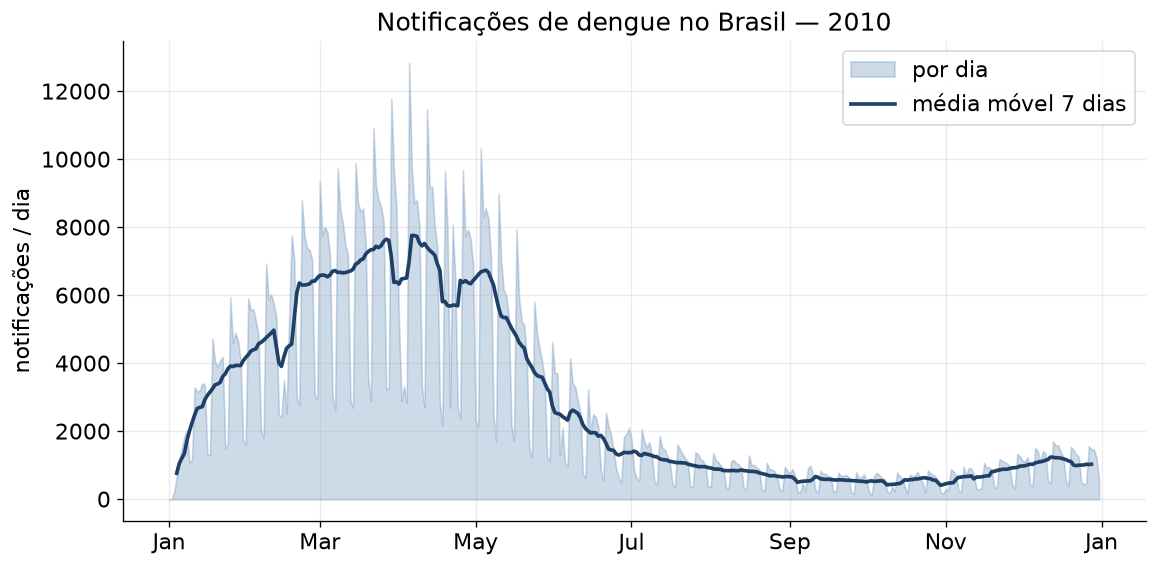

In [3]:
fig, ax = plt.subplots()
ax.fill_between(NAC_DATAS, nac["notif"].to_numpy(), color=AZUL, alpha=0.25, label="por dia")
ax.plot(NAC_DATAS, nac["notif_7d"].to_numpy(), color=AZUL_ESC, lw=2.2, label="média móvel 7 dias")
ax.set_title("Notificações de dengue no Brasil — 2010")
ax.set_ylabel("notificações / dia")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper right")
plt.show()

A epidemia se concentra no **primeiro semestre**, com pico em **março–abril**
e queda acentuada a partir de junho.

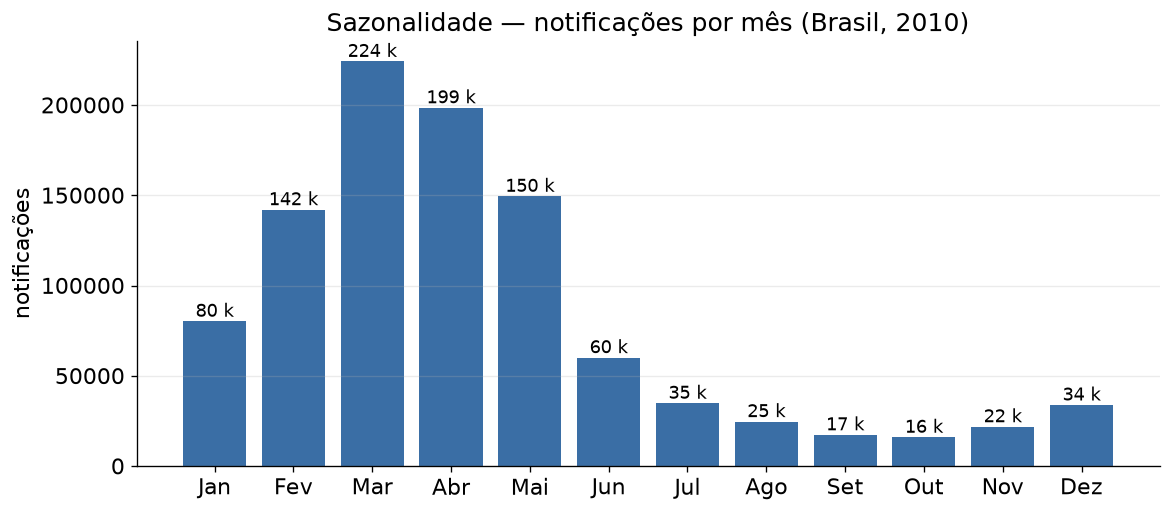

In [4]:
n = mensal["notif"].to_list()
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(MESES, n, color=AZUL)
ax.set_title("Sazonalidade — notificações por mês (Brasil, 2010)")
ax.set_ylabel("notificações")
for i, v in enumerate(n):
    ax.text(i, v, f"{v/1000:.0f} k", ha="center", va="bottom", fontsize=11)
ax.grid(axis="x")
plt.show()

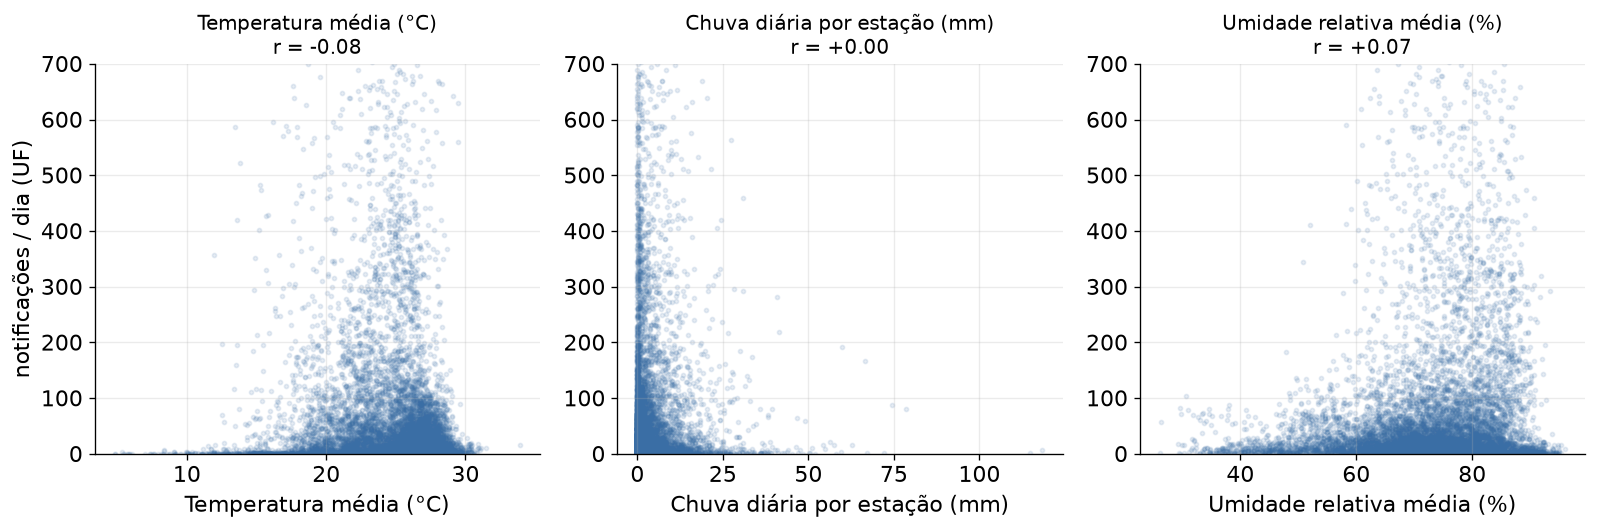

In [5]:
pares = [("temp_media_c", "Temperatura média (°C)"),
         ("precip_mm_estacao", "Chuva diária por estação (mm)"),
         ("umidade_media_pct", "Umidade relativa média (%)")]
y = df["notificacoes_dengue"].to_numpy()
fig, axs = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, (col, lab) in zip(axs, pares):
    ax.scatter(df[col].to_numpy(), y, s=6, alpha=0.12, color=AZUL)
    ax.set_title(f"{lab}\nr = {corr(df, col, 'notificacoes_dengue'):+.2f}", fontsize=12)
    ax.set_xlabel(lab)
    ax.set_ylim(0, 700)
axs[0].set_ylabel("notificações / dia (UF)")
plt.tight_layout()
plt.show()

No nível **diário e contemporâneo** o sinal do clima é **fraco** — esperado:
o efeito da meteorologia sobre a dengue tem defasagem de semanas.

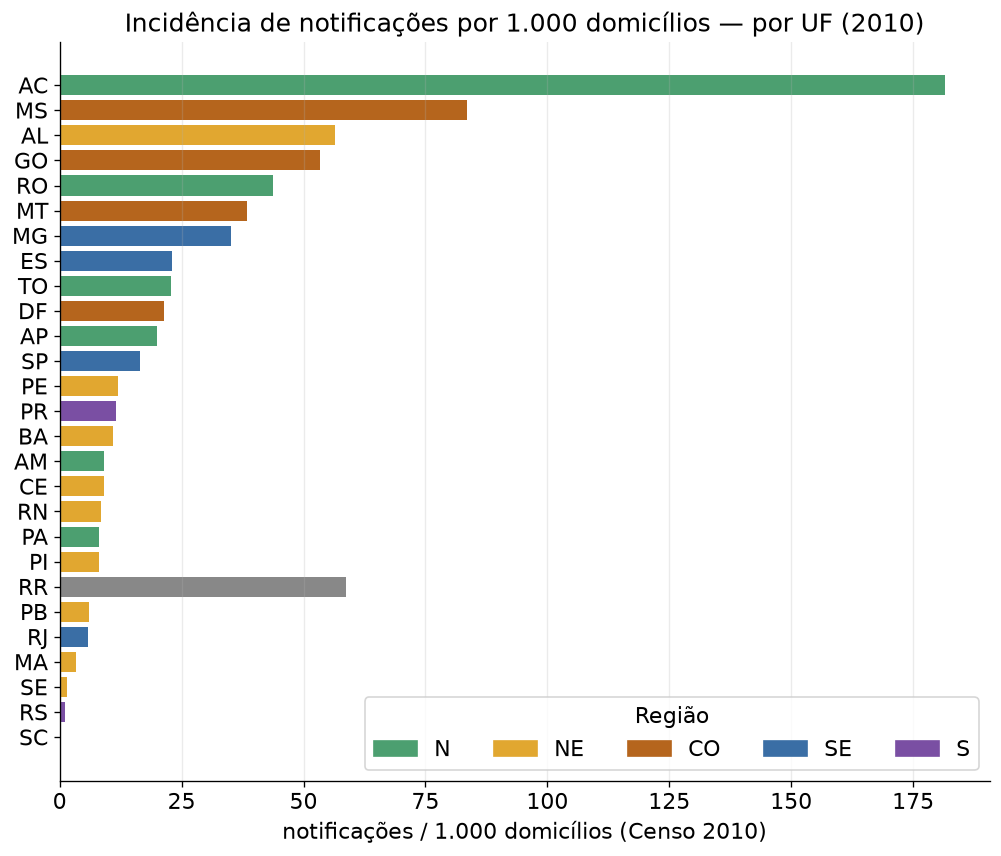

In [6]:
ufs = inc["UF"].to_list()
vals = inc["inc_1000"].to_list()
cores = [CORES_REGIAO.get(x, "#888") for x in inc["REGIAO"].to_list()]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(ufs, vals, color=cores)
ax.set_title("Incidência de notificações por 1.000 domicílios — por UF (2010)")
ax.set_xlabel("notificações / 1.000 domicílios (Censo 2010)")
ax.grid(axis="y")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in CORES_REGIAO.values()]
ax.legend(handles, CORES_REGIAO.keys(), title="Região", ncol=5, loc="lower right")
plt.show()

Forte **contraste regional**: Acre, Mato Grosso do Sul, Goiás e o Centro-Oeste / Norte
no topo; boa parte do Nordeste e do Sul na base.

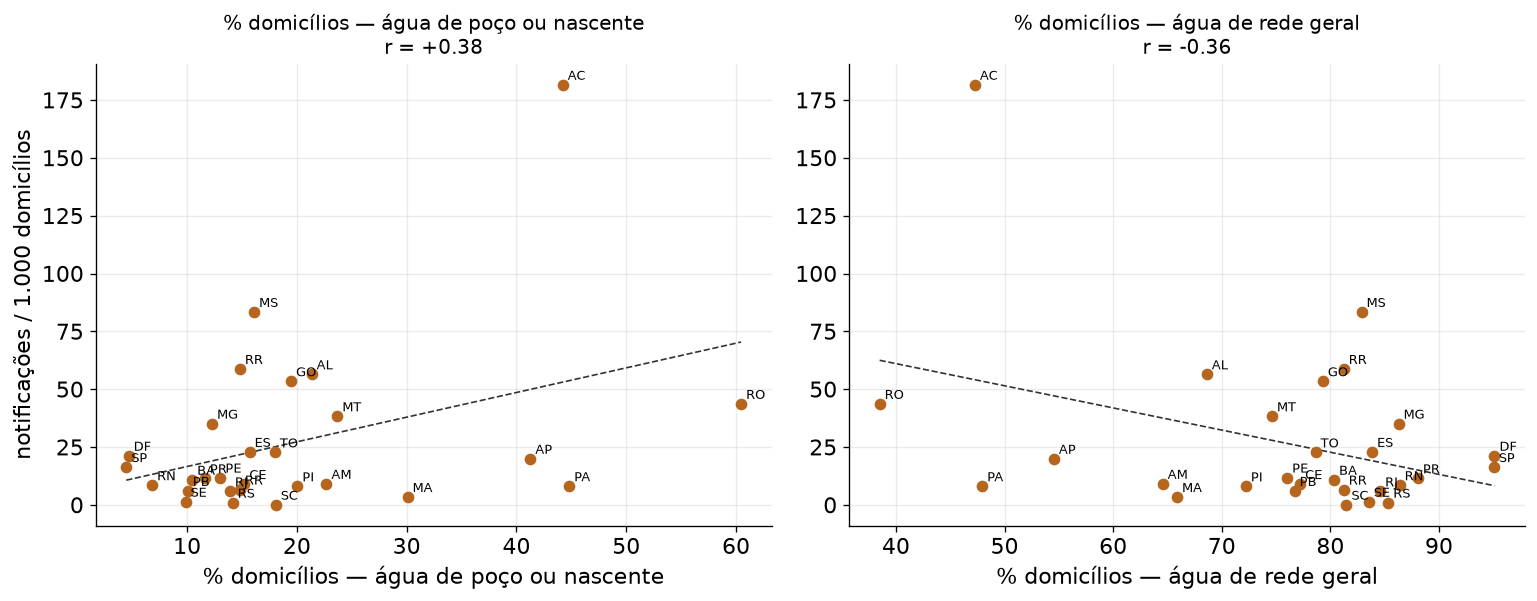

In [7]:
pares = [("censo_pct_agua_poco_nascente", "% domicílios — água de poço ou nascente"),
         ("censo_pct_agua_rede_geral", "% domicílios — água de rede geral")]
uf_lab = inc["UF"].to_list()
yy = np.array(inc["inc_1000"].to_list())
fig, axs = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, (col, lab) in zip(axs, pares):
    xx = np.array(inc[col].to_list()) * 100
    ax.scatter(xx, yy, color=TERRA, zorder=3)
    for x_i, y_i, t in zip(xx, yy, uf_lab):
        ax.annotate(t, (x_i, y_i), fontsize=8, xytext=(3, 3), textcoords="offset points")
    m, b = np.polyfit(xx, yy, 1)
    xs = np.array([xx.min(), xx.max()])
    ax.plot(xs, m * xs + b, color="#333", lw=1, ls="--")
    ax.set_title(f"{lab}\nr = {np.corrcoef(xx, yy)[0, 1]:+.2f}", fontsize=12)
    ax.set_xlabel(lab)
axs[0].set_ylabel("notificações / 1.000 domicílios")
plt.tight_layout()
plt.show()

A **infraestrutura** dá um sinal mais nítido que o clima contemporâneo:
mais **água de poço/nascente** → maior incidência (r ≈ **+0,37**);
mais **rede geral** → menor (r ≈ **−0,35**). Coerente com a hipótese de
**armazenamento de água** como criadouro.

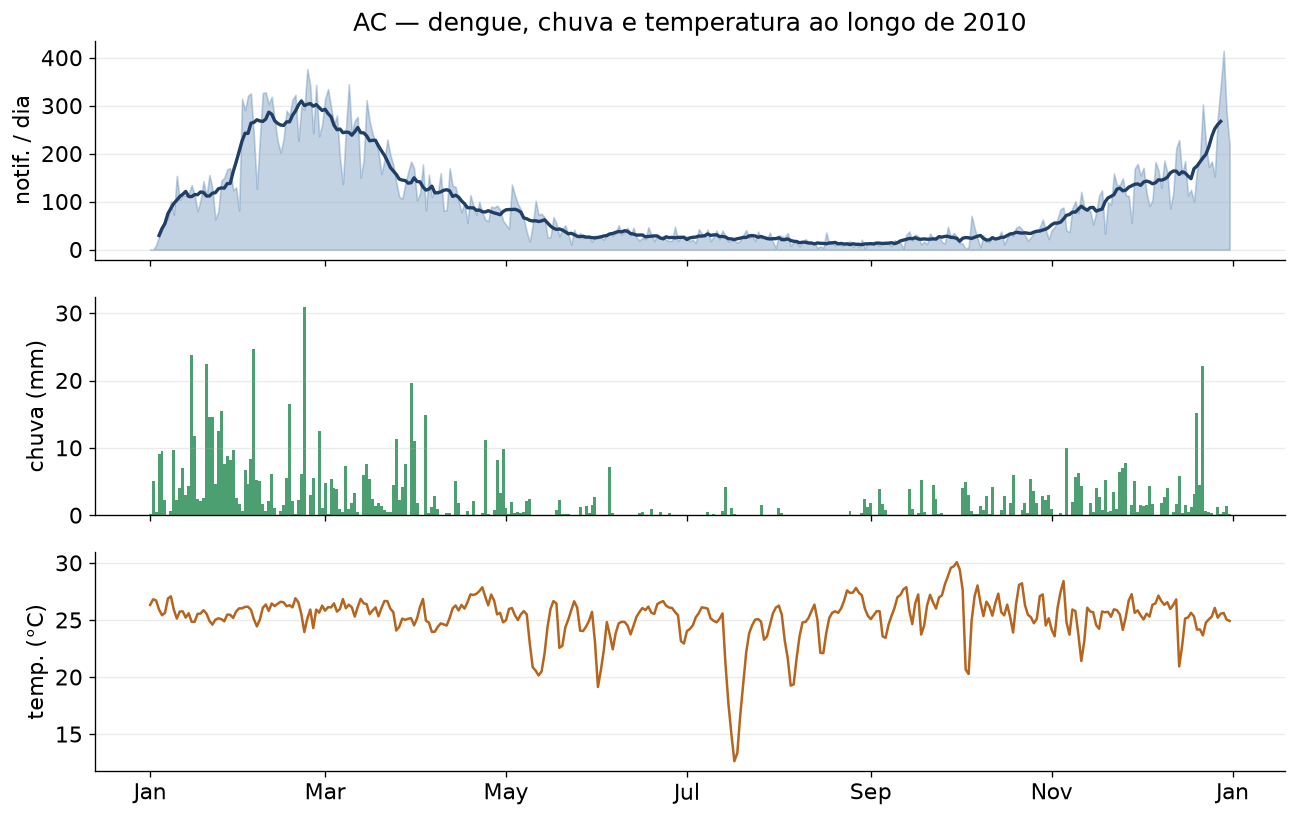

In [8]:
uf = "AC"
s = df.filter(pl.col("UF") == uf).sort("DATA")
d = s["DATA"].to_list()
notif_7d = s["notificacoes_dengue"].rolling_mean(7, center=True).to_numpy()

fig, axs = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axs[0].fill_between(d, s["notificacoes_dengue"].to_numpy(), color=AZUL, alpha=0.3)
axs[0].plot(d, notif_7d, color=AZUL_ESC, lw=2)
axs[0].set_ylabel("notif. / dia")
axs[0].set_title(f"{uf} — dengue, chuva e temperatura ao longo de 2010")
axs[1].bar(d, s["precip_mm_estacao"].to_numpy(), color=VERDE, width=1)
axs[1].set_ylabel("chuva (mm)")
axs[2].plot(d, s["temp_media_c"].to_numpy(), color=TERRA)
axs[2].set_ylabel("temp. (°C)")
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
for a in axs:
    a.grid(axis="x")
plt.tight_layout()
plt.show()

No Acre, a onda de notificações **precede o auge das chuvas** e coincide com o
período mais quente do verão — sugerindo defasagem entre clima e casos.

## Limitações

- **Granularidade UF × dia** dilui a heterogeneidade interna — a dengue é um
  fenômeno **municipal/local**.
- **Sem defasagem temporal:** o efeito do clima tem *lag* de semanas; correlações
  diárias contemporâneas são naturalmente fracas.
- **Cobertura do INMET:** o nº de estações varia por UF; a média estadual pode não
  representar as áreas urbanas de transmissão.
- **`CLASSI_FIN` em 2010:** convivência dos esquemas antigo e novo de classificação.
- **Censo:** um único ano (2010), tratado como característica estrutural fixa.
- Recorte de **um único ano**.

## Conclusões e próximos passos

- A base integrada **funciona** e reproduz fatos conhecidos: pico no **outono**
  (mar–mai) e forte contraste regional.
- **Infraestrutura > clima contemporâneo** como sinal: água de poço/nascente
  (r ≈ +0,37) vs. rede geral / esgoto (r ≈ −0,35 / −0,25).
- Clima **diário contemporâneo**: correlação fraca — esperado sem defasagem.

**Próximos passos**

- Estender para **múltiplos anos**.
- Descer ao nível de **município** (`ID_MUNICIP` + coordenadas das estações).
- Modelar com **defasagem** (clima de 3–8 semanas antes).
- Normalizar por **população**, não por domicílio.

# Obrigado!

Base e notebooks: `recorte_inmet_pysus_2010.ipynb` ·
`INMET_x_PYSUS_2010_diario_uf.parquet`